# Customer Intelligence System
**Classification** (Random Forest, XGBoost) + **Clustering** (K-Means, DBSCAN)

Dataset: Country-data.csv

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, silhouette_score)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## Load and Prepare Data

In [2]:
df = pd.read_csv("Country-data.csv")
print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# check missing values
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [4]:
countries = df["country"]
features = df.drop(columns=["country"])
feature_names = features.columns.tolist()

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print("Features standardized.")

Features standardized.


## Create Target Labels

Since the dataset has no labels, we create a composite development score from key indicators and split countries into 3 categories.

In [5]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

dev_score = (
    normalize(features["gdpp"]) * 0.30
    + normalize(features["income"]) * 0.25
    + normalize(features["life_expec"]) * 0.25
    + (1 - normalize(features["child_mort"])) * 0.20
)

t1, t2 = dev_score.quantile(0.33), dev_score.quantile(0.66)
status_labels = pd.cut(dev_score, bins=[-np.inf, t1, t2, np.inf],
                       labels=["Underdeveloped", "Developing", "Developed"])
df["development_status"] = status_labels

le = LabelEncoder()
y = le.fit_transform(status_labels)

print("Label distribution:")
print(status_labels.value_counts())

Label distribution:
Developed         57
Underdeveloped    55
Developing        55
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

## Correlation Heatmap

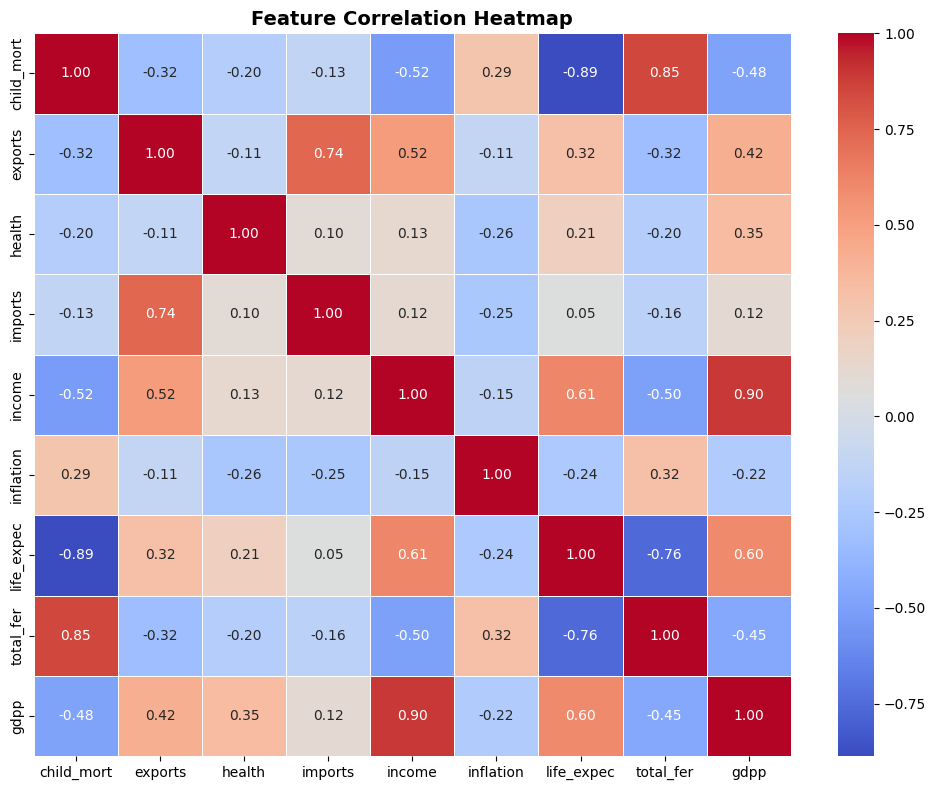

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Classification

### Random Forest

In [8]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("Baseline accuracy:", round(accuracy_score(y_test, rf.predict(X_test)), 4))

Baseline accuracy: 0.9412


In [9]:
# hyperparameter tuning
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 200, 300], "max_depth": [5, 10, None],
     "min_samples_split": [2, 5], "min_samples_leaf": [1, 2]},
    cv=5, scoring="accuracy", n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_preds = rf_best.predict(X_test)

print("Best params:", rf_search.best_params_)
print("Tuned accuracy:", round(accuracy_score(y_test, rf_preds), 4))
print()
print(classification_report(y_test, rf_preds, target_names=le.classes_))

Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Tuned accuracy: 0.9706

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       1.00      0.91      0.95        11
Underdeveloped       0.92      1.00      0.96        11

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



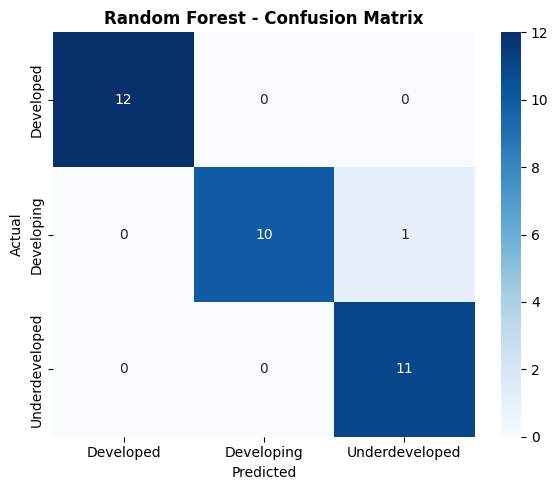

In [10]:
# confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Random Forest - Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

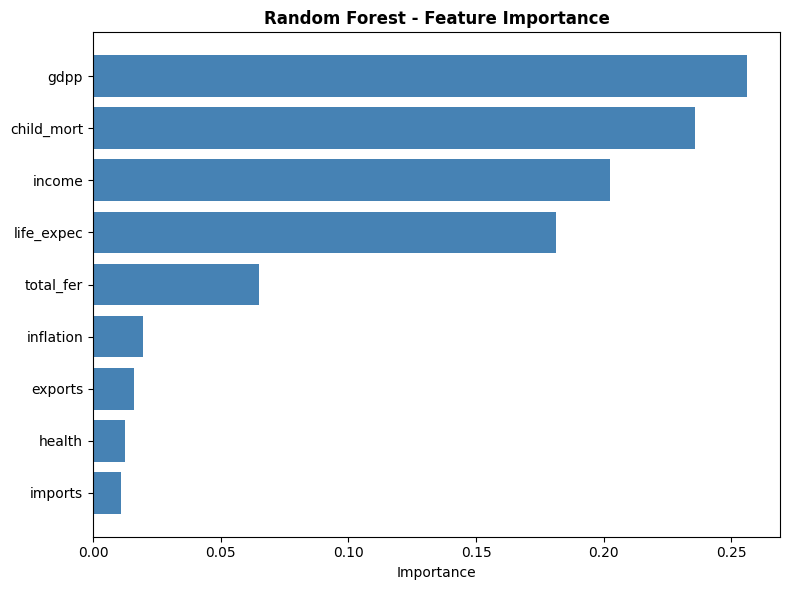

In [11]:
# feature importance
rf_imp = rf_best.feature_importances_
idx = np.argsort(rf_imp)
plt.figure(figsize=(8, 6))
plt.barh(np.array(feature_names)[idx], rf_imp[idx], color="steelblue")
plt.title("Random Forest - Feature Importance", fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### XGBoost

In [12]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                     random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
print("Baseline accuracy:", round(accuracy_score(y_test, xgb.predict(X_test)), 4))

Baseline accuracy: 0.9412


In [13]:
# hyperparameter tuning
xgb_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                  random_state=42, verbosity=0),
    {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7],
     "learning_rate": [0.01, 0.1, 0.2], "subsample": [0.8, 1.0],
     "colsample_bytree": [0.8, 1.0]},
    cv=5, scoring="accuracy", n_jobs=-1
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
xgb_preds = xgb_best.predict(X_test)

print("Best params:", xgb_search.best_params_)
print("Tuned accuracy:", round(accuracy_score(y_test, xgb_preds), 4))
print()
print(classification_report(y_test, xgb_preds, target_names=le.classes_))

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Tuned accuracy: 0.9412

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       1.00      0.82      0.90        11
Underdeveloped       0.85      1.00      0.92        11

      accuracy                           0.94        34
     macro avg       0.95      0.94      0.94        34
  weighted avg       0.95      0.94      0.94        34



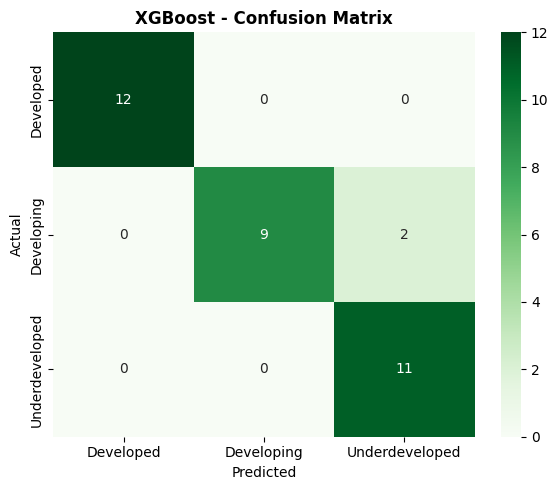

In [14]:
# confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost - Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

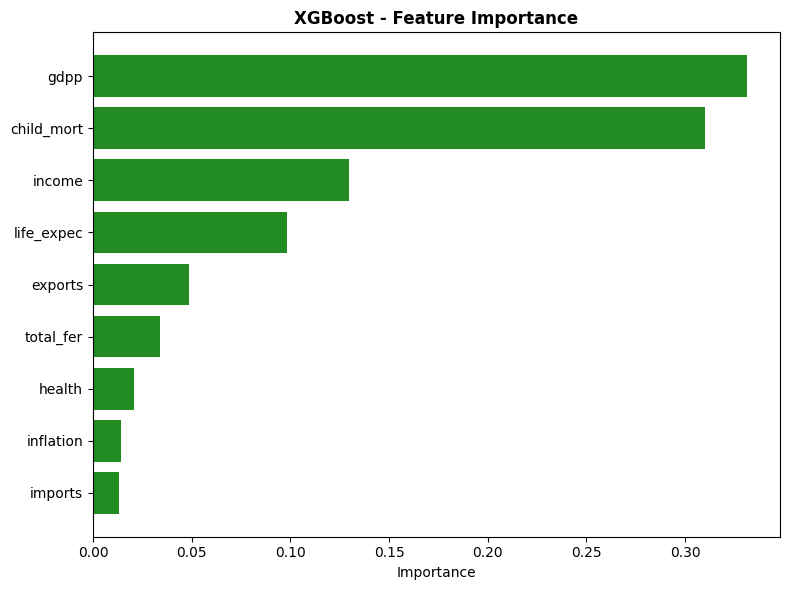

In [15]:
# feature importance
xgb_imp = xgb_best.feature_importances_
idx2 = np.argsort(xgb_imp)
plt.figure(figsize=(8, 6))
plt.barh(np.array(feature_names)[idx2], xgb_imp[idx2], color="forestgreen")
plt.title("XGBoost - Feature Importance", fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Model Comparison

In [16]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 Score (weighted)"],
    "Random Forest": [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds, average="weighted"),
        recall_score(y_test, rf_preds, average="weighted"),
        f1_score(y_test, rf_preds, average="weighted")
    ],
    "XGBoost": [
        accuracy_score(y_test, xgb_preds),
        precision_score(y_test, xgb_preds, average="weighted"),
        recall_score(y_test, xgb_preds, average="weighted"),
        f1_score(y_test, xgb_preds, average="weighted")
    ]
})
comparison

,Metric,Random Forest,XGBoost
0,Accuracy,0.970588,0.941176
1,Precision (weighted),0.973039,0.950226
2,Recall (weighted),0.970588,0.941176
3,F1 Score (weighted),0.970527,0.940686


In [17]:
# cross validation
rf_cv = cross_val_score(rf_best, X_scaled, y, cv=5, scoring="accuracy")
xgb_cv = cross_val_score(xgb_best, X_scaled, y, cv=5, scoring="accuracy")
print(f"5-Fold CV - RF:  {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")
print(f"5-Fold CV - XGB: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")

5-Fold CV - RF:  0.9221 (+/- 0.0149)
5-Fold CV - XGB: 0.9344 (+/- 0.0285)


## Clustering

In [18]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

PCA explained variance: 63.13%


### K-Means

In [19]:
inertia_list = []
sil_list = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, km.labels_))
    print(f"  k={k}: Inertia={km.inertia_:.1f}, Silhouette={sil_list[-1]:.4f}")

  k=2: Inertia=1050.2, Silhouette=0.2874
  k=3: Inertia=831.4, Silhouette=0.2833
  k=4: Inertia=700.5, Silhouette=0.2960
  k=5: Inertia=620.2, Silhouette=0.2993
  k=6: Inertia=558.5, Silhouette=0.2287
  k=7: Inertia=495.8, Silhouette=0.2477
  k=8: Inertia=457.6, Silhouette=0.2388


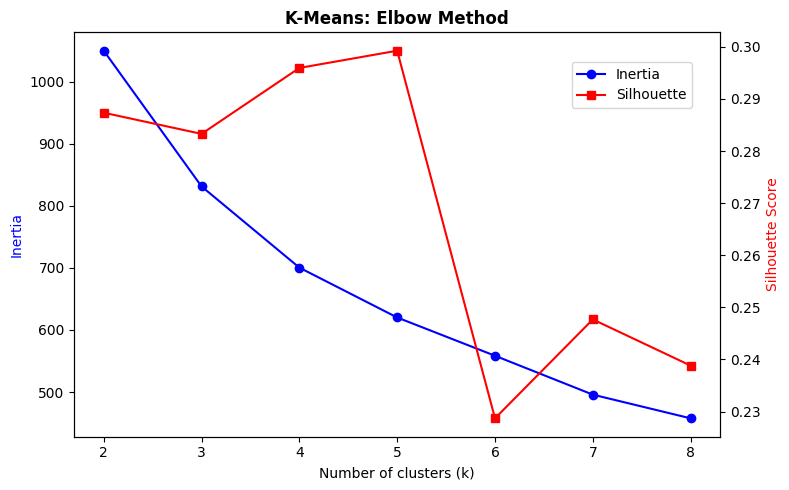

In [20]:
# elbow plot
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(range(2, 9), inertia_list, "bo-", label="Inertia")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="blue")
ax2 = ax1.twinx()
ax2.plot(range(2, 9), sil_list, "rs-", label="Silhouette")
ax2.set_ylabel("Silhouette Score", color="red")
plt.title("K-Means: Elbow Method", fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

Best k = 5


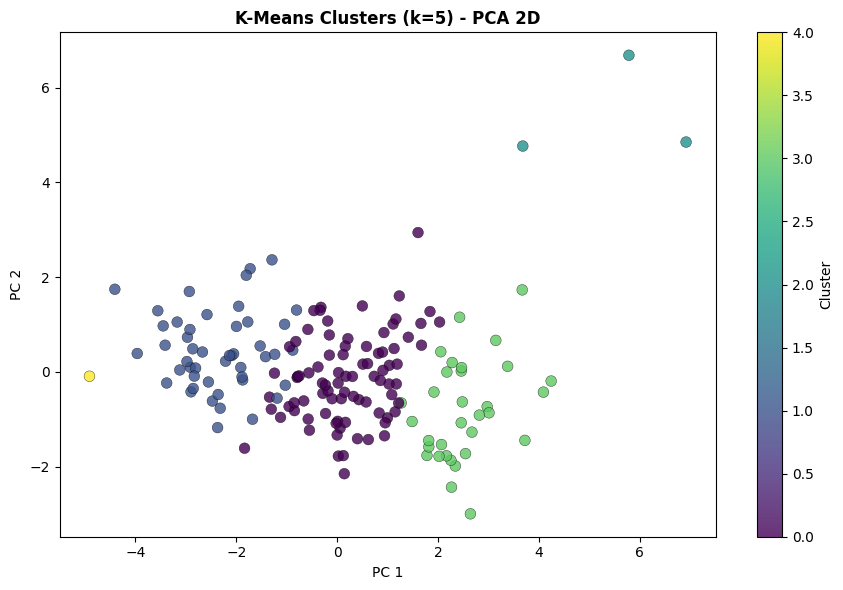

In [21]:
optimal_k = range(2, 9)[np.argmax(sil_list)]
print(f"Best k = {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels = kmeans_final.fit_predict(X_scaled)
df["kmeans_cluster"] = km_labels

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="viridis",
                      edgecolors="k", linewidths=0.3, alpha=0.8, s=60)
plt.title(f"K-Means Clusters (k={optimal_k}) - PCA 2D", fontweight="bold")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

### DBSCAN

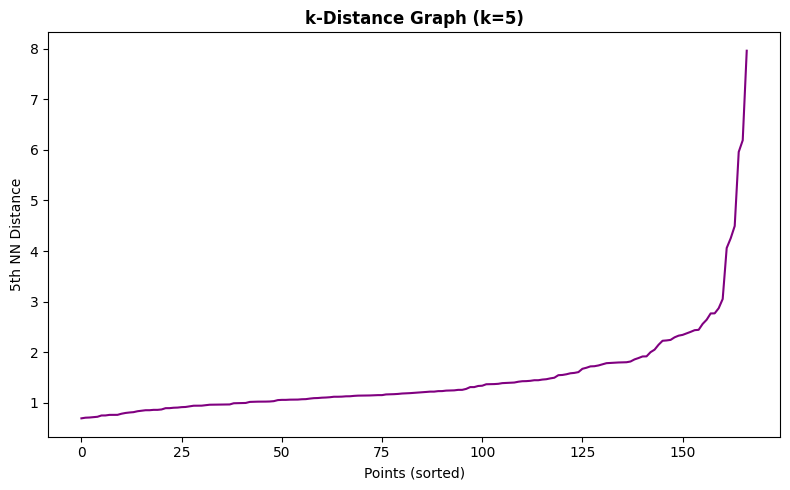

In [22]:
# k-distance graph to estimate eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_dist, color="purple")
plt.title("k-Distance Graph (k=5)", fontweight="bold")
plt.xlabel("Points (sorted)")
plt.ylabel("5th NN Distance")
plt.tight_layout()
plt.show()

In [23]:
# find best eps and min_samples
best_score = -1
best_eps = None
best_min = None
for eps_val in np.arange(1.5, 4.5, 0.5):
    for min_pts in [3, 4, 5]:
        db = DBSCAN(eps=eps_val, min_samples=min_pts)
        lbl = db.fit_predict(X_scaled)
        n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
        if n_clust >= 2:
            s = silhouette_score(X_scaled, lbl)
            if s > best_score:
                best_score, best_eps, best_min = s, eps_val, min_pts

print(f"Best eps={best_eps}, min_samples={best_min}, silhouette={best_score:.4f}")

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min)
db_labels = dbscan_final.fit_predict(X_scaled)
df["dbscan_cluster"] = db_labels

num_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
num_noise = (db_labels == -1).sum()
print(f"Clusters: {num_clusters}, Noise points: {num_noise}")

Best eps=1.5, min_samples=3, silhouette=0.1540
Clusters: 2, Noise points: 25


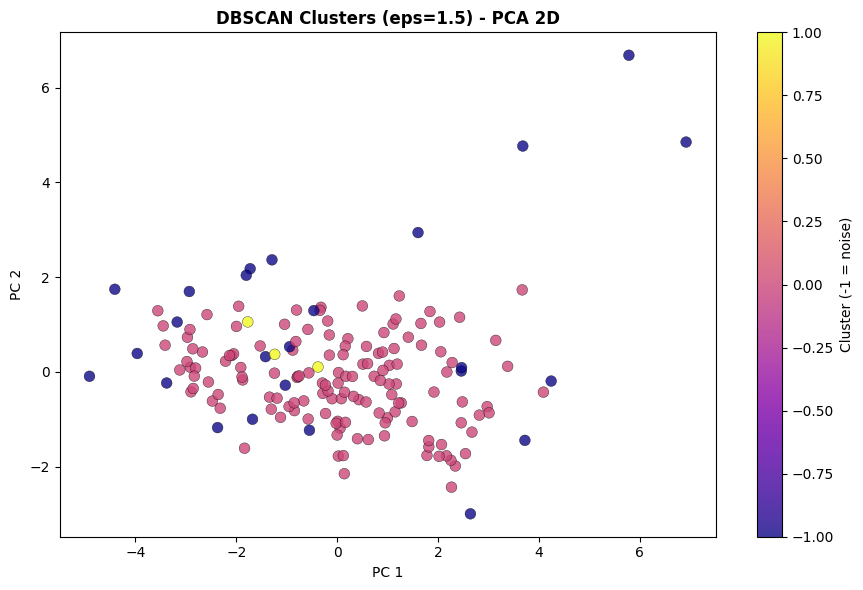

In [24]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap="plasma",
                      edgecolors="k", linewidths=0.3, alpha=0.8, s=60)
plt.title(f"DBSCAN Clusters (eps={best_eps}) - PCA 2D", fontweight="bold")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(scatter, label="Cluster (-1 = noise)")
plt.tight_layout()
plt.show()

In [25]:
# silhouette comparison
print("Clustering Silhouette Scores:")
print(f"  K-Means: {silhouette_score(X_scaled, km_labels):.4f}")
if num_clusters >= 2:
    print(f"  DBSCAN:  {best_score:.4f}")

Clustering Silhouette Scores:
  K-Means: 0.2993
  DBSCAN:  0.1540


## Actionable Segmentation Insights

In [26]:
cluster_means = df.groupby("kmeans_cluster")[feature_names].mean().round(2)
print("Cluster Profiles:")
cluster_means

Cluster Profiles:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


In [27]:
# describe each cluster
worst = cluster_means["child_mort"].idxmax()
best = cluster_means["child_mort"].idxmin()

for c in sorted(df["kmeans_cluster"].unique()):
    row = cluster_means.loc[c]
    n = (df["kmeans_cluster"] == c).sum()
    if row["child_mort"] == cluster_means["child_mort"].max():
        print(f"  Cluster {c} ({n} countries): Underdeveloped - high child mortality, low GDP")
    elif row["child_mort"] == cluster_means["child_mort"].min():
        print(f"  Cluster {c} ({n} countries): Developed - low child mortality, high GDP")
    else:
        print(f"  Cluster {c} ({n} countries): Developing - moderate indicators")

  Cluster 0 (84 countries): Developing - moderate indicators
  Cluster 1 (47 countries): Developing - moderate indicators
  Cluster 2 (3 countries): Developed - low child mortality, high GDP
  Cluster 3 (32 countries): Developing - moderate indicators
  Cluster 4 (1 countries): Underdeveloped - high child mortality, low GDP


In [28]:
# top 10 countries needing aid
df["dev_score"] = dev_score.values
top_need = df.nsmallest(10, "dev_score")[["country", "child_mort", "income",
                                          "life_expec", "gdpp", "development_status"]]
print("Top 10 Countries Needing Aid:")
top_need

Top 10 Countries Needing Aid:


,country,child_mort,income,life_expec,gdpp,development_status
66,Haiti,208.0,1500,32.1,662,Underdeveloped
31,Central African Republic,149.0,888,47.5,446,Underdeveloped
132,Sierra Leone,160.0,1220,55.0,399,Underdeveloped
32,Chad,150.0,1930,56.5,897,Underdeveloped
87,Lesotho,99.7,2380,46.5,1170,Underdeveloped
97,Mali,137.0,1870,59.5,708,Underdeveloped
64,Guinea-Bissau,114.0,1390,55.6,547,Underdeveloped
37,"Congo, Dem. Rep.",116.0,609,57.5,334,Underdeveloped
112,Niger,123.0,814,58.8,348,Underdeveloped
106,Mozambique,101.0,918,54.5,419,Underdeveloped


In [29]:
print("Recommendations:")
print("1. Prioritize funding for Underdeveloped cluster countries")
print("2. Healthcare programs for countries with child mortality > 80 per 1000")
print("3. Economic aid for countries with GDP per capita < $1000")
print("4. Monitor Developing countries to prevent backsliding")

Recommendations:
1. Prioritize funding for Underdeveloped cluster countries
2. Healthcare programs for countries with child mortality > 80 per 1000
3. Economic aid for countries with GDP per capita < $1000
4. Monitor Developing countries to prevent backsliding
